## **Import & Setup**

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal

## **Load the Data**

In [ ]:
full_matrix = pd.read_parquet("../data/interaction_matrix_raw.parquet")
features    = pd.read_parquet("../data/neighborhood_features.parquet")
division_map_file = pd.read_csv("../../02. General Data - Directories/3. NACE Data/NACE_Division_Codes.csv")

neighbourhoods = list(full_matrix.columns)
centrality_by_neighbourhood = features.loc[neighbourhoods, "distance_to_volos_center_km"]

In [3]:
# The mapping file is missing ~36 divisions
# We supplement the ones that appear in the analysis
supplement = {
    32: "Other manufacturing",
    41: "Construction of buildings",
    45: "Trade & repair of motor vehicles",
    47: "Retail trade (exc. motor vehicles)",
    56: "Food and beverage service activities",
    69: "Legal and accounting activities",
    74: "Other professional/scientific/technical",
    84: "Public administration and defence",
    93: "Sports, amusement and recreation",
}
division_name = dict(zip(pd.to_numeric(division_map_file["Division Code"], errors="coerce"),
                         division_map_file["Division Description"]))
division_name.update(supplement)

## **Inspect Centrality per NACE Division**

In [ ]:
# Per-division centrality profile (business-weighted, with 95% CI)
MIN_BUSINESSES = 30

business_records = []
for nace in full_matrix.index:
    division = int(nace)
    counts = full_matrix.loc[nace]
    for neighbourhood in neighbourhoods:
        n = int(counts[neighbourhood])
        if n > 0:
            business_records.extend([(division, c[neighbourhood])] * n)
businesses = pd.DataFrame(business_records, columns=["division", "centrality"])

profile = businesses.groupby("division")["centrality"].agg(["mean", "std", "count"]).reset_index()
profile = profile[profile["count"] >= MIN_BUSINESSES].copy()
profile["ci95"] = 1.96 * profile["std"] / np.sqrt(profile["count"])
profile["label"] = profile["division"].map(lambda d: f"{d} – {str(division_name.get(d, 'Unknown'))[:42]}")
profile = profile.sort_values("mean")
print(profile[["label", "mean", "ci95", "count"]].to_string(index=False))

                                          label     mean     ci95  count
18 – Printing and reproduction of recorded medi 1.154601 0.228242     46
                   86 – Human health activities 1.285564 0.196344    445
    94 – Activities of membership organisations 1.579105 0.339855     42
         96 – Other personal service activities 1.668155 0.487807    120
      56 – Food and beverage service activities 1.715560 0.174574    298
                 41 – Construction of buildings 1.811435 0.708777     52
95 – Repair of computers and personal and house 1.883947 0.827313     41
46 – Wholesale trade, except of motor vehicles  1.952333 0.443985    111
                                 85 – Education 1.962891 0.359086    217
28 – Manufacture of machinery and equipment n.e 1.986578 0.369419     64
                       32 – Other manufacturing 1.992978 0.773808     78
71 – Architectural and engineering activities;  2.017022 0.783596     71
                    68 – Real estate activities 2.0

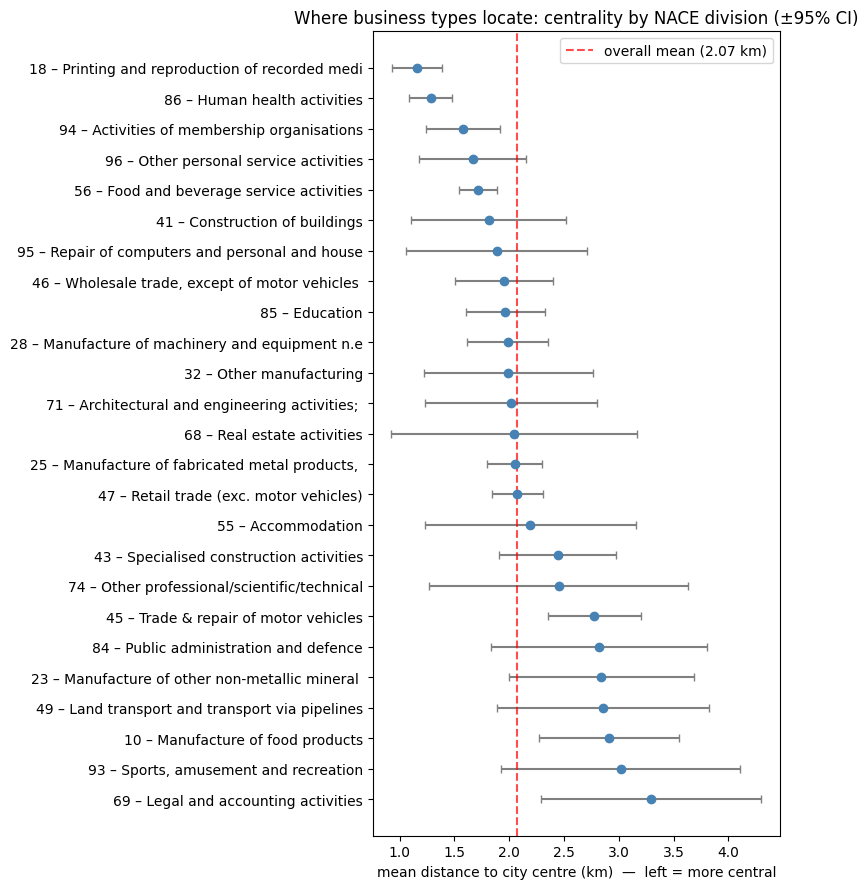

In [ ]:
# Ranked figure of mean +/- 95% CI
ordered = profile.sort_values("mean", ascending=False)
fig, ax = plt.subplots(figsize=(8, 9))
ax.errorbar(ordered["mean"], ordered["label"], xerr=ordered["ci95"], fmt="o", color="steelblue", ecolor="gray", capsize=3)
ax.axvline(businesses["centrality"].mean(), color="red", linestyle="--", alpha=0.7, label=f"overall mean ({businesses['centrality'].mean():.2f} km)")
ax.set_xlabel("mean distance to city centre (km)  —  left = more central")
ax.set_title("Where business types locate: centrality by NACE division (±95% CI)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/location_drivers_centrality_by_division.png", dpi=100, bbox_inches="tight")
plt.show()

In [ ]:
# Statistical test that proves the business type is correlated with the centrality
kept_divisions = profile["division"].tolist()
groups = [g["centrality"].values for division, g in businesses[businesses["division"].isin(kept_divisions)].groupby("division")]
h_statistic, p_value = kruskal(*groups)
print(f"Kruskal-Wallis across {len(kept_divisions)} divisions: H = {h_statistic:.0f}, p = {p_value:.1e}")

Kruskal-Wallis across 25 divisions: H = 304, p = 2.6e-50
